In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
plt.style.use("ggplot")
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [23]:
df.shape

(7043, 21)

In [24]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [26]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [30]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [39]:
pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
).isna().sum()

np.int64(11)

In [43]:
df.customerID.nunique()

7043

In [45]:
df.Churn.value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [58]:
df_cat = df.select_dtypes(include="object").drop(columns=["customerID", "TotalCharges"])
df_cat.apply(lambda x: (x.nunique(), x.unique())).transpose()

C:\Users\arman\AppData\Local\Temp\ipykernel_29684\1142476940.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_cat = df.select_dtypes(include="object").drop(columns=["customerID", "TotalCharges"])


,0,1
gender,2,"[Female, Male]"
Partner,2,"[Yes, No]"
Dependents,2,"[No, Yes]"
PhoneService,2,"[No, Yes]"
MultipleLines,3,"[No phone service, No, Yes]"
InternetService,3,"[DSL, Fiber optic, No]"
OnlineSecurity,3,"[No, Yes, No internet service]"
OnlineBackup,3,"[Yes, No, No internet service]"
DeviceProtection,3,"[No, Yes, No internet service]"
TechSupport,3,"[No, Yes, No internet service]"


In [60]:
df.PaymentMethod.unique()

<StringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str

In [ ]:
print("""
Data Quality Exploration 
      - On a 7043 clients disponibles dans le dataset, 1869 ont quitté le service (Churn = Yes), ce qui représente environ 26.6% du total des clients.
      - On a 21 colonnes, 7043 lignes, 20 variables (dont la variable cible : Churn), le customerID est un identifiant unique pour chaque client.
      Il ne sera pas utilisé pour la modélisation. Avec 4 valeurs uniques max pour les catégorielles, pas besoin de les regrouper ou de faire du target encoding, on pourra faire du one-hot encoding directement.

      - Valeurs manquantes : 'TotalCharges' a 11 valeurs manquantes, ce qui représente une petite fraction du dataset (11/7043 ≈ 0.16%).
      Ces valeurs manquantes pourraient être imputées ou supprimées selon la stratégie choisie pour gérer les données manquantes.
      On a vérifié qu'il n'y avait pas des champs vides d'espaces dans les variables catégorielles, ce qui est une bonne nouvelle pour la qualité des données.

      - On a 3 features numériques : 'tenure', 'MonthlyCharges' et 'SeniorCitizen'. Le reste sont des features catégorielles. 
      'SeniorCitizen' est une variable binaire indiquant si le client est un senior (1) ou non (0).
      'TotalCharges' est une variable numérique qui semble être un montant total facturé au client, mais elle est actuellement de type objet (string), ce qui suggère qu'elle pourrait contenir des valeurs non numériques ou des espaces vides.

      - La variable cible 'Churn' est déséquilibrée, avec environ 26.6% de clients ayant quitté le service. Cela pourrait en théorie nécessiter des techniques de gestion du déséquilibre des classes lors de la modélisation.
      Néanmoins nous avons suffisament de volumes de données pour les deux classes, donc nous allons d'abord essayer de modéliser sans appliquer de techniques de rééquilibrage, et voir les résultats obtenus.
""")


Data Exploration 
      - On a 7043 clients disponibles dans le dataset, 1869 ont quitté le service (Churn = Yes), ce qui représente environ 26.6% du total des clients.
      - On a 21 colonnes, 7043 lignes, 20 variables (dont la variable cible : Churn), le customerID est un identifiant unique pour chaque client.
      Il ne sera pas utilisé pour la modélisation. Avec 4 valeurs uniques max pour les catégorielles, pas besoin de les regrouper ou de faire du target encoding, on pourra faire du one-hot encoding directement.

      - Valeurs manquantes : 'TotalCharges' a 11 valeurs manquantes, ce qui représente une petite fraction du dataset (11/7043 ≈ 0.16%).
      Ces valeurs manquantes pourraient être imputées ou supprimées selon la stratégie choisie pour gérer les données manquantes.
      On a vérifié qu'il n'y avait pas des champs vides d'espaces dans les variables catégorielles, ce qui est une bonne nouvelle pour la qualité des données.

      - On a 3 features numériques : 'tenure'

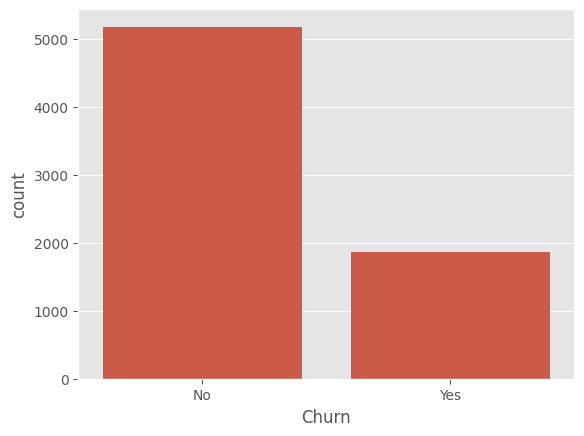

In [44]:
sns.countplot(data=df, x="Churn")
plt.show()